#### Objective
Build a classifier to predict the service category for unknown cases of customers. The example focuses on using demographic data, such as region, age, and marital, to predict usage patterns.

The target field, called custcat, has four possible service categories that correspond to the four customer groupss:

*   Basic Service
*   E-Service
*   Plus Service
*   Total Service

The algorithm used is K-nearest neighbors.

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("teleCust1000t.csv")
df.sample(10)

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
621,1,18,56,0,22,296.0,2,25,0.0,0,1,1
185,3,24,26,0,2,32.0,3,2,0.0,0,3,1
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
419,2,1,20,0,1,21.0,2,0,0.0,1,2,1
955,3,71,48,0,25,288.0,3,19,0.0,0,1,1
442,3,19,30,1,10,33.0,4,1,0.0,0,3,4
740,3,34,29,0,5,26.0,3,4,0.0,1,2,2
602,2,7,27,0,3,39.0,3,2,0.0,0,1,1
218,2,72,61,1,39,76.0,3,21,0.0,0,2,4
248,3,33,55,1,21,64.0,3,10,0.0,1,3,1


In [3]:
# get value counts for class-wise distribution
df["custcat"].value_counts()

# balanced dataset, hence, no resampling necessary

,count
custcat,
3,281
1,266
4,236
2,217


In [26]:
# correlation matrix
df_correlation = df.corr()
correlation_values = np.abs(df_correlation["custcat"].drop('custcat')).sort_values(ascending=False)
correlation_values
# ed and tenure have the highest effect on target variable
# retire and gender have the least effect on target variable

,custcat
ed,0.193864
tenure,0.166691
income,0.134525
employ,0.110011
marital,0.083836
reside,0.082022
address,0.067913
age,0.056909
region,0.023771
retire,0.008908


<Axes: >

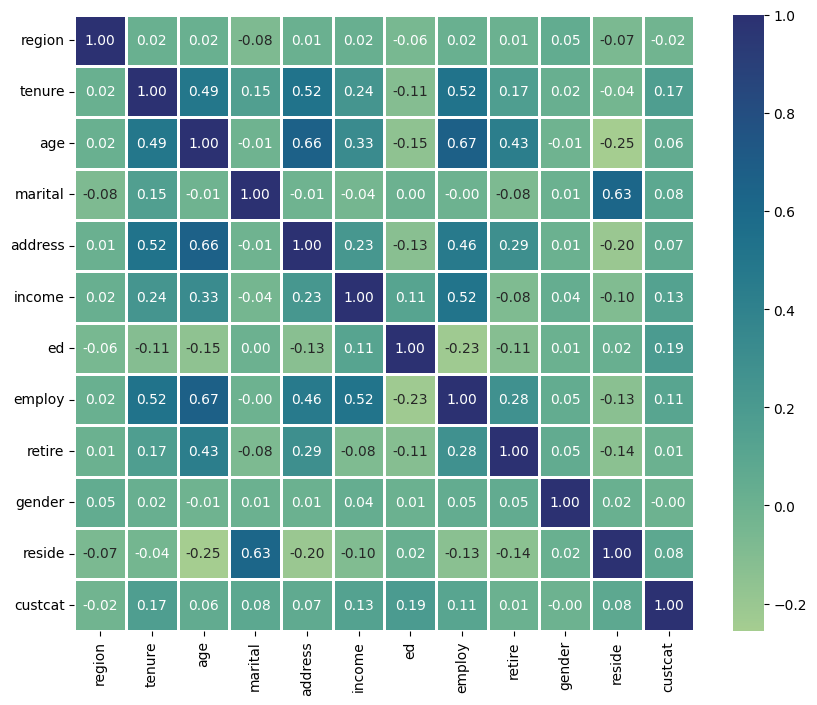

In [17]:
# heatmap of correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df_correlation, cmap='crest', annot=True, fmt='.2f', linewidth=1)

In [27]:
# separate feature and label
X = df.drop(columns='custcat')
y = df['custcat']
print(X.shape)
print(y.shape)

(1000, 11)
(1000,)


In [30]:
# normalize the features
std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)
print(X[:10])

[[-0.02696767 -1.055125    0.18450456  1.0100505  -0.25303431 -0.12650641
   1.0877526  -0.5941226  -0.22207644 -1.03459817 -0.23065004]
 [ 1.19883553 -1.14880563 -0.69181243  1.0100505  -0.4514148   0.54644972
   1.9062271  -0.5941226  -0.22207644 -1.03459817  2.55666158]
 [ 1.19883553  1.52109247  0.82182601  1.0100505   1.23481934  0.35951747
  -1.36767088  1.78752803 -0.22207644  0.96655883 -0.23065004]
 [-0.02696767 -0.11831864 -0.69181243 -0.9900495   0.04453642 -0.41625141
  -0.54919639 -1.09029981 -0.22207644  0.96655883 -0.92747794]
 [-0.02696767 -0.58672182 -0.93080797  1.0100505  -0.25303431 -0.44429125
  -1.36767088 -0.89182893 -0.22207644 -1.03459817  1.16300577]
 [-0.02696767  0.2564039  -0.21382135 -0.9900495   0.54048764  0.00434618
  -0.54919639  0.49746728 -0.22207644  0.96655883 -0.92747794]
 [ 1.19883553  0.44376517 -1.56812942  1.0100505  -0.94736601 -0.54710399
  -0.54919639 -0.69335804 -0.22207644  0.96655883  1.85983368]
 [-0.02696767  0.11588295 -0.53248207 -0.

In [32]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X train shape: ", X_train.shape)
print("X test shape: ", X_test.shape)
print("y train shape: ", y_train.shape)
print("y test shape: ", y_test.shape)

X train shape:  (800, 11)
X test shape:  (200, 11)
y train shape:  (800,)
y test shape:  (200,)


In [33]:
# train the model
k=6
knn_classifier = KNeighborsClassifier(n_neighbors=k)
knn_classifier.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=6)

In [35]:
# predict the values
y_predict = knn_classifier.predict(X_test)
print(y_predict[:10])

[4 2 3 3 3 3 4 3 1 4]


In [36]:
# model accuracy
accuracy_score = accuracy_score(y_test, y_predict)
print("Accuracy of the model on test data is: ", accuracy_score)

Accuracy of the model is:  0.33


In [ ]:
# choosing correct value of k